In [3]:
import pandas as pd
df = pd.read_csv("Crime Final Project.csv", low_memory=False)
grouped = (
    df
    .groupby(["Neighborhood", "NIBRS_Crime_Against"])
    .size()
    .reset_index(name="Crime_Count")
)
categories = ["Person", "Property", "Group B"]
for cat in categories:
    safest_5 = (
        grouped[grouped["NIBRS_Crime_Against"] == cat]
        .sort_values("Crime_Count", ascending=True) 
        .head(5)
    )  
    print(f"\nTop 5 safest neighborhoods for {cat} crimes (fewest incidents):")
    print(safest_5)



Top 5 safest neighborhoods for Person crimes (fewest incidents):
       Neighborhood NIBRS_Crime_Against  Crime_Count
267       Ridgemont              Person            3
263   Regent Square              Person            5
327  Swisshelm Park              Person            7
271     Saint Clair              Person            7
81        Chartiers              Person            9

Top 5 safest neighborhoods for Property crimes (fewest incidents):
      Neighborhood NIBRS_Crime_Against  Crime_Count
272    Saint Clair            Property            8
268      Ridgemont            Property            9
82       Chartiers            Property           16
148           Hays            Property           18
220  New Homestead            Property           18

Top 5 safest neighborhoods for Group B crimes (fewest incidents):
      Neighborhood NIBRS_Crime_Against  Crime_Count
270    Saint Clair             Group B            6
80       Chartiers             Group B           12
266      Ridg

In this cell, I load the crime dataset and create a grouped table that counts how many crimes of each type occur in each neighborhood. I then print out the five neighborhoods with the fewest Person, Property, and Group B crimes. This gives an initial, unweighted picture of which areas seem safest when I only look at the number of incidents. At this stage, every crime is treated the same, so the output is helpful for spotting patterns, but it does not yet account for how serious those crimes are or how large each neighborhood is.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Crime Final Project.csv", low_memory=False)

grouped = (
    df
    .groupby(["Neighborhood", "NIBRS_Crime_Against"])
    .size()
    .reset_index(name="Crime_Count")
)

Here, I reload the crime data and group it by neighborhood and crime-against category again, but this time I am preparing the data specifically for visualization. By storing the grouped results in a DataFrame instead of just printing them, I can reuse this structure to create bar charts for each crime category. This step matters because it sets up a consistent base for comparing neighborhoods and makes it easier to transition from raw counts to visual evidence in the next cells.

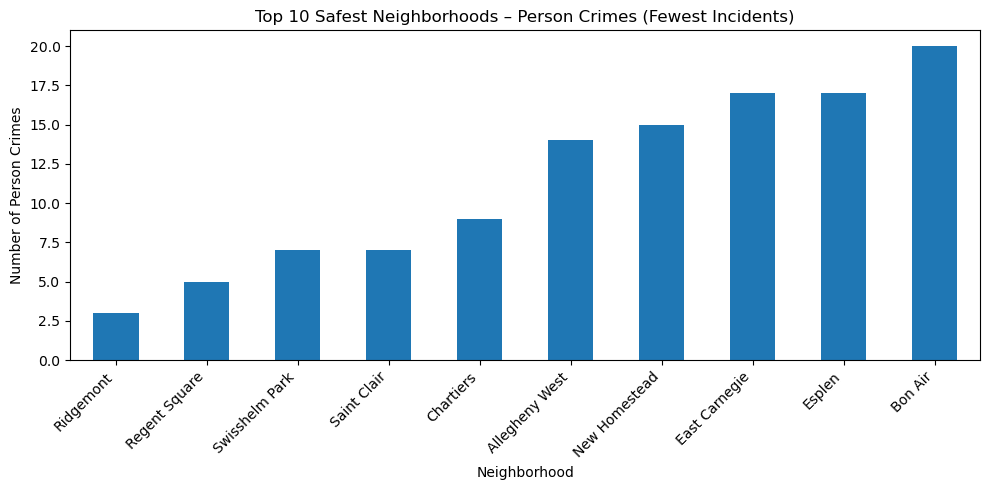

In [3]:
safest_person = (
    grouped[grouped["NIBRS_Crime_Against"] == "Person"]
    .sort_values("Crime_Count", ascending=True)
    .head(10)
)

ax = safest_person.plot(
    kind="bar",
    x="Neighborhood",
    y="Crime_Count",
    legend=False,
    figsize=(10, 5),
    title="Top 10 Safest Neighborhoods – Person Crimes (Fewest Incidents)"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Person Crimes")
plt.tight_layout()
plt.show()

This cell focuses on Person crimes, which represent offenses directly against individuals. I identify the ten neighborhoods with the lowest number of Person crimes and display them in a bar chart. This graph helps me visually highlight the areas that seem safest from a personal safety perspective when I only count how many incidents occur. Although this is still based on raw counts, it begins to support my argument by showing that some neighborhoods clearly experience fewer people-focused crimes than others, setting up a contrast for the more refined, severity-weighted analysis later.


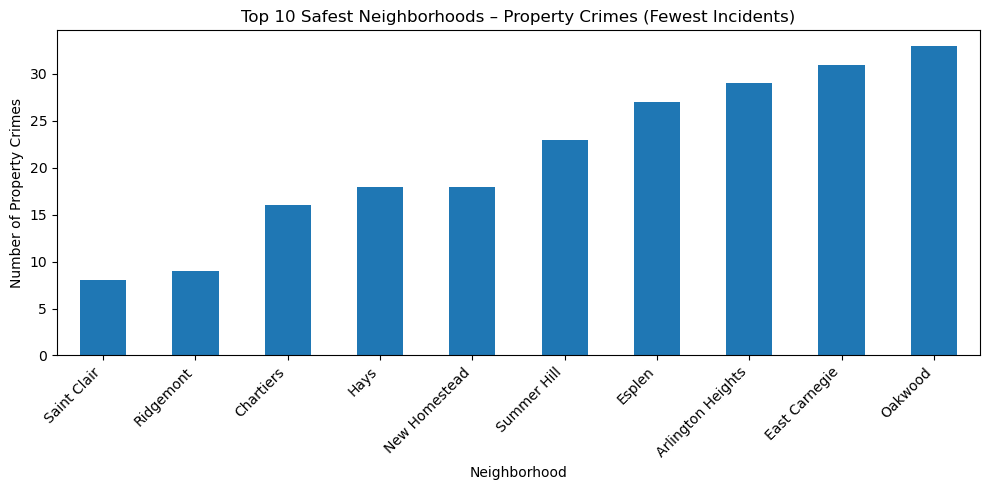

In [4]:
safest_property = (
    grouped[grouped["NIBRS_Crime_Against"] == "Property"]
    .sort_values("Crime_Count", ascending=True)
    .head(10)
)

ax = safest_property.plot(
    kind="bar",
    x="Neighborhood",
    y="Crime_Count",
    legend=False,
    figsize=(10, 5),
    title="Top 10 Safest Neighborhoods – Property Crimes (Fewest Incidents)"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Property Crimes")
plt.tight_layout()
plt.show()

In this cell, I repeat the same process but for Property crimes. I select the ten neighborhoods with the fewest property-related incidents and plot them in a bar chart. This allows me to compare which neighborhoods are safest in terms of protecting homes, belongings, and physical spaces rather than personal harm. Seen together with the Person crimes graph, this visualization shows that safety can look different depending on what type of harm I focus on, reinforcing the idea that a single, unweighted crime count does not fully capture neighborhood safety.


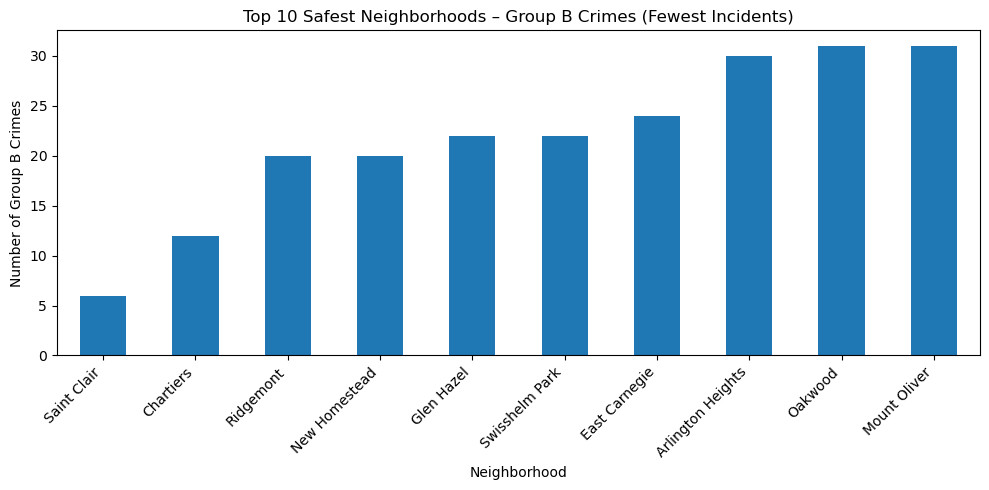

In [5]:
safest_groupb = (
    grouped[grouped["NIBRS_Crime_Against"] == "Group B"]
    .sort_values("Crime_Count", ascending=True)
    .head(10)
)

ax = safest_groupb.plot(
    kind="bar",
    x="Neighborhood",
    y="Crime_Count",
    legend=False,
    figsize=(10, 5),
    title="Top 10 Safest Neighborhoods – Group B Crimes (Fewest Incidents)"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Group B Crimes")
plt.tight_layout()
plt.show()

This cell applies the same method to Group B crimes, which include less severe offenses compared to crimes against persons or property. I graph the ten neighborhoods with the lowest counts of Group B incidents. While these crimes are generally less serious, they still contribute to how people experience a neighborhood. Comparing this chart with the previous ones shows that some neighborhoods perform consistently well across all categories, while others may mainly avoid minor offenses. This further motivates the need for a severity-weighted approach, because not all categories should influence safety judgments in the same way.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# load data
crime_df = pd.read_csv("Crime Final Project.csv", low_memory=False)
pop_df   = pd.read_csv("preliminarycitypittsburghneighborhood_pl94171summary-2.csv")

# fix neighborhood names (strip spaces, normalize dashes)
def fix_name(s):
    if pd.isna(s):
        return s
    return s.strip().replace("–", "-").replace("—", "-")

crime_df["Neighborhood_norm"] = crime_df["Neighborhood"].map(fix_name)
pop_df["Neighborhood_norm"]   = pop_df["Neighborhood"].map(fix_name)

# combine some separate neighborhoods so they line up with the population file
combine = {
    "Arlington": "Arlington - Arlington Heights (Combined)",
    "Arlington Heights": "Arlington - Arlington Heights (Combined)",
    "Central Business District": "Central Business District (Downtown)",
    "Chartiers": "Chartiers City",
    "Mount Oliver": "Mt. Oliver",
    "Saint Clair": "St. Clair",
    "Southshore": "South Shore",
    "Spring Hill-City View": "Spring Hill-City"
}

crime_df["Neighborhood_fixed"] = crime_df["Neighborhood_norm"].replace(combine)


In this cell, I move beyond simple crime counts and start preparing the data for a more precise safety metric. I load both the crime dataset and the population dataset, then clean and standardize neighborhood names so they match across files. Some neighborhoods that appear separately in the crime data are combined in the population file, so I explicitly merge those labels. This careful alignment is important, because any mismatch between crime counts and population totals would distort later calculations and could cause a neighborhood to look safer or more dangerous than it truly is.


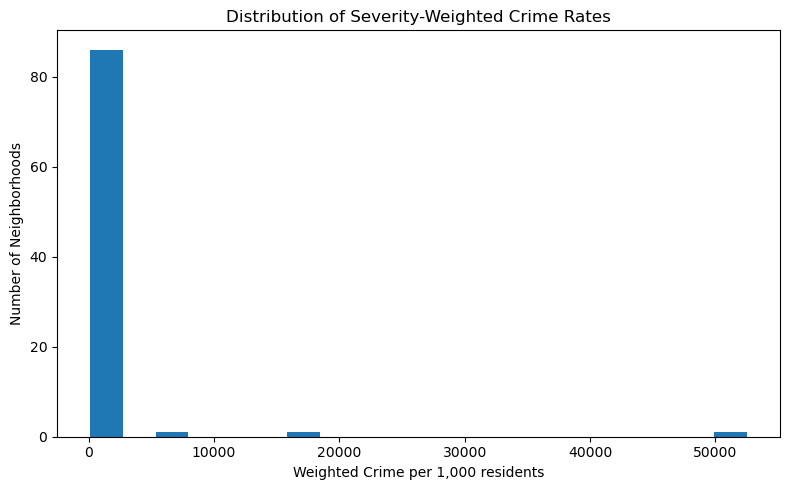

In [5]:
# group crime by neighborhood + crime-against category
grouped = (
    crime_df
    .dropna(subset=["Neighborhood_fixed", "NIBRS_Crime_Against"])
    .groupby(["Neighborhood_fixed", "NIBRS_Crime_Against"])
    .size()
    .reset_index(name="Crime_Count")
)

# pivot: one row per neighborhood, columns for Person / Property / Group B
crime_pivot = (
    grouped
    .pivot(index="Neighborhood_fixed", columns="NIBRS_Crime_Against", values="Crime_Count")
    .fillna(0)
    .reset_index()
)

# make sure all three columns exist
for col in ["Person", "Property", "Group B"]:
    if col not in crime_pivot.columns:
        crime_pivot[col] = 0

# pull 2020 population and align neighborhood names
pop_2020 = (
    pop_df[["Neighborhood_norm", "2020_Total_Population"]]
    .dropna()
    .rename(columns={"Neighborhood_norm": "Neighborhood_fixed"})
)

# merge crime + population
crime_metrics = crime_pivot.merge(pop_2020, on="Neighborhood_fixed", how="inner")

# avoid divide-by-zero
crime_metrics = crime_metrics[crime_metrics["2020_Total_Population"] > 0]

# apply severity weights (Option 2)
person_wt = 5
property_wt = 2
groupb_wt = 1

crime_metrics["Weighted_Crime_Total"] = (
    person_wt * crime_metrics["Person"] +
    property_wt * crime_metrics["Property"] +
    groupb_wt * crime_metrics["Group B"]
)

# weighted crime per 1,000 residents
crime_metrics["Weighted_Crime_per_1000"] = (
    crime_metrics["Weighted_Crime_Total"] / crime_metrics["2020_Total_Population"] * 1000
)

# scale crime so that higher = safer (1 = safest, 0 = worst)
c_min = crime_metrics["Weighted_Crime_per_1000"].min()
c_max = crime_metrics["Weighted_Crime_per_1000"].max()

if c_max == c_min:
    crime_metrics["Crime_Scaled"] = 1.0
else:
    scaled_raw = (crime_metrics["Weighted_Crime_per_1000"] - c_min) / (c_max - c_min)
    crime_metrics["Crime_Scaled"] = 1 - scaled_raw

# sort by weighted crime per 1,000 (ascending = safest first)
crime_metrics_sorted = crime_metrics.sort_values("Weighted_Crime_per_1000", ascending=True)

# quick look at the table
crime_metrics_sorted.head()

# ----- graph for this cell: distribution of weighted crime per 1,000 -----
plt.figure(figsize=(8, 5))
plt.hist(crime_metrics["Weighted_Crime_per_1000"], bins=20)
plt.xlabel("Weighted Crime per 1,000 residents")
plt.ylabel("Number of Neighborhoods")
plt.title("Distribution of Severity-Weighted Crime Rates")
plt.tight_layout()
plt.show()


This cell builds the core of my severity-weighted, per-capita crime metric. First, I summarize the number of Person, Property, and Group B crimes for each neighborhood. Then I merge this with the 2020 population data so every neighborhood has both its crime totals and its population size. Using the weights I chose, I give more impact to Person crimes, moderate weight to Property crimes, and the least weight to Group B offenses. I then compute a weighted crime score per 1,000 residents, which adjusts for neighborhood size and reflects both how often crimes occur and how serious they are. Finally, I scale the values so that higher scores indicate safer neighborhoods and plot the distribution of weighted crime rates. This step is where my main argument takes shape: instead of relying on raw counts, I build a metric that combines severity and population to describe safety in a more meaningful way.


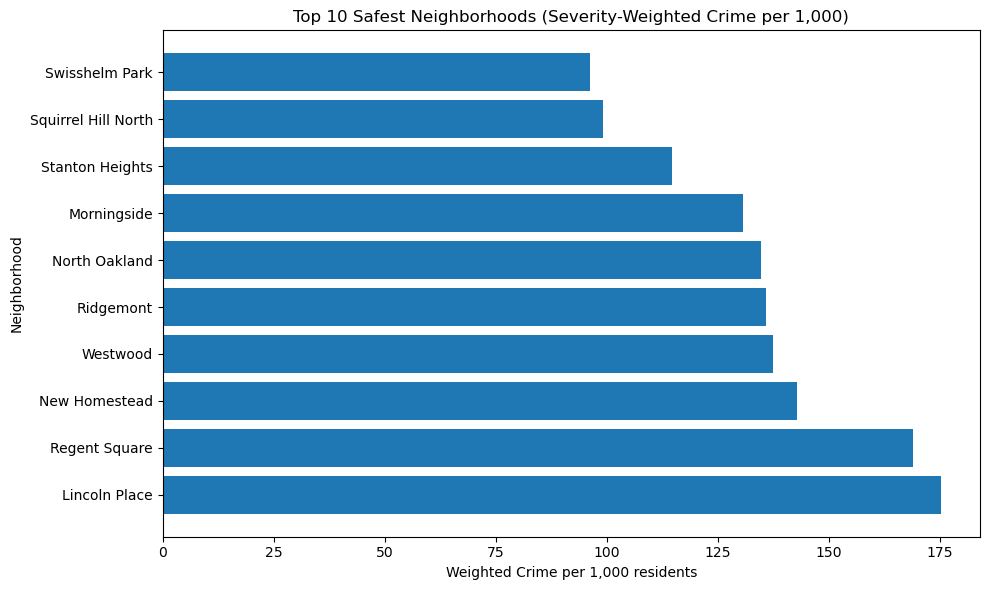

In [6]:
# take the 10 safest (lowest weighted crime per 1,000 residents)
top10_safest = crime_metrics_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_safest["Neighborhood_fixed"], top10_safest["Weighted_Crime_per_1000"])
plt.xlabel("Weighted Crime per 1,000 residents")
plt.ylabel("Neighborhood")
plt.title("Top 10 Safest Neighborhoods (Severity-Weighted Crime per 1,000)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Here, I use the severity-weighted crime per 1,000 residents to identify the ten safest neighborhoods overall. By plotting these neighborhoods in a horizontal bar chart, I make it easy to see which areas have the lowest adjusted crime rates once both seriousness and population size are taken into account. This graph directly supports my conclusion that severity-weighted, per-capita crime reveals a more accurate picture of safety than simple incident counts. Neighborhoods that might have looked similar based on raw numbers become clearly distinct when I factor in how harmful the crimes are and how many people live there.


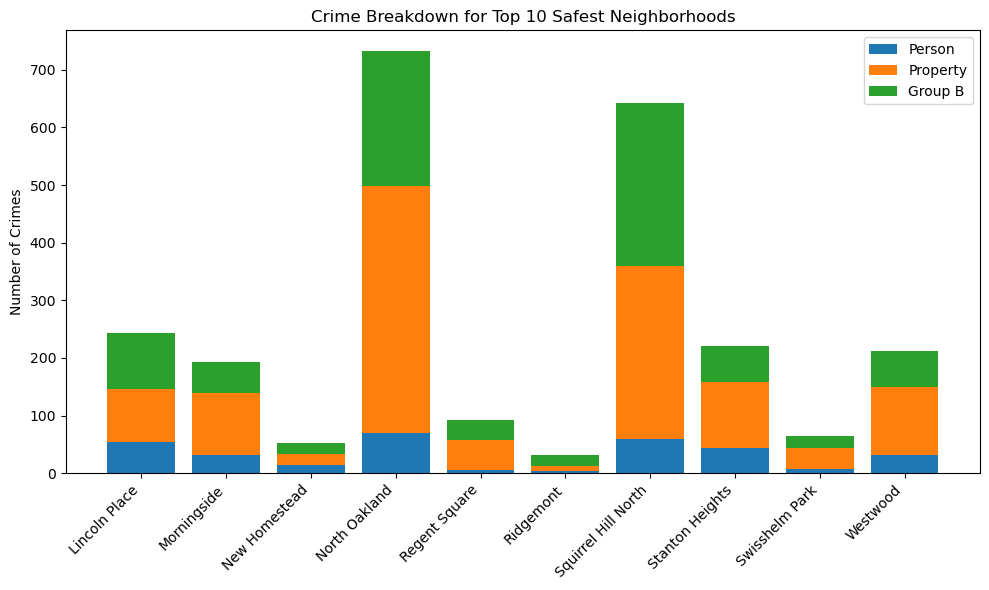

In [7]:
# filter the original pivot to only the top10 safest neighborhoods
top10_names = top10_safest["Neighborhood_fixed"].tolist()

top10_breakdown = (
    crime_pivot[crime_pivot["Neighborhood_fixed"].isin(top10_names)]
    .set_index("Neighborhood_fixed")
    [["Person", "Property", "Group B"]]
    .sort_index()
)

plt.figure(figsize=(10, 6))
bottom = None

for col in ["Person", "Property", "Group B"]:
    if bottom is None:
        bottom = top10_breakdown[col]
        plt.bar(top10_breakdown.index, top10_breakdown[col], label=col)
    else:
        plt.bar(top10_breakdown.index, top10_breakdown[col], bottom=bottom, label=col)
        bottom = bottom + top10_breakdown[col]

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Crimes")
plt.title("Crime Breakdown for Top 10 Safest Neighborhoods")
plt.legend()
plt.tight_layout()
plt.show()


This cell looks more closely at the ten safest neighborhoods by breaking their crime totals into Person, Property, and Group B categories. The stacked bar chart shows not just how many crimes occur in each of these neighborhoods, but also what kinds of crimes they tend to have. This breakdown matters because it demonstrates that the neighborhoods ranked safest by my severity-weighted metric are not just low in total incidents, but also avoid large numbers of serious person crimes. In other words, this visualization helps justify the weighting scheme by showing that the highest-ranking neighborhoods are truly safer in terms of both volume and impact of crime. 


## Conclusion ## 

Overall, this sequence of cells moves from simple crime counts to a more careful and realistic way of thinking about neighborhood safety. The early graphs that rank neighborhoods by raw counts of Person, Property, and Group B crimes are useful for building intuition, but they treat all incidents as equally important and ignore how many people live in each area. By contrast, the later steps combine crime severity and population into a single, weighted crime rate per 1,000 residents and then scale that measure so safer neighborhoods receive higher scores. This transformation changes the story: instead of just asking where crimes happen, I can now ask where serious harm is least likely for each resident.

This approach supports my conclusion that severity-weighted, per-capita crime offers a more accurate depiction of safety than raw incident totals. A neighborhood with a modest number of minor offenses may still feel relatively safe, while one with fewer but more violent crimes may feel far more dangerous. The final rankings and breakdowns show that when I weigh Person crimes more heavily and adjust for population, the neighborhoods that rise to the top are the ones that genuinely protect residents from both frequent and severe harm. These crime results will later become one part of a broader quality of life index, where crime, complaints, and trees work together to describe the overall conditions in each Pittsburgh neighborhood.
